In [1]:
! pip install mlflow


[notice] A new release of pip is available: 23.3 -> 25.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('../data/housing_normalized.csv')
df

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
0,0.000000,0.2,0.073442,0.0,0.309129,0.577505,0.628998,0.308996,0.000000,0.225941,0.287234,0.089680,0.422222
1,0.000411,0.0,0.262406,0.0,0.165975,0.547998,0.775053,0.400545,0.043478,0.112971,0.553191,0.204470,0.368889
2,0.000410,0.0,0.262406,0.0,0.165975,0.694386,0.585288,0.400545,0.043478,0.112971,0.553191,0.063466,0.660000
3,0.000509,0.0,0.068281,0.0,0.143154,0.658555,0.422175,0.514848,0.086957,0.071130,0.648936,0.033389,0.631111
4,0.001227,0.0,0.068281,0.0,0.143154,0.687105,0.511727,0.514848,0.086957,0.071130,0.648936,0.099338,0.693333
...,...,...,...,...,...,...,...,...,...,...,...,...,...
450,0.001101,0.0,0.455339,0.0,0.381743,0.580954,0.670576,0.140804,0.000000,0.177824,0.893617,0.219095,0.386667
451,0.000762,0.0,0.455339,0.0,0.381743,0.490324,0.751599,0.120858,0.000000,0.177824,0.893617,0.202815,0.346667
452,0.001065,0.0,0.455339,0.0,0.381743,0.654340,0.904051,0.108332,0.000000,0.177824,0.893617,0.107892,0.420000
453,0.002020,0.0,0.455339,0.0,0.381743,0.619467,0.885928,0.131441,0.000000,0.177824,0.893617,0.131071,0.377778


In [4]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]
X.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT
0,0.000000,0.2,0.073442,0.0,0.309129,0.577505,0.628998,0.308996,0.000000,0.225941,0.287234,0.089680
1,0.000411,0.0,0.262406,0.0,0.165975,0.547998,0.775053,0.400545,0.043478,0.112971,0.553191,0.204470
2,0.000410,0.0,0.262406,0.0,0.165975,0.694386,0.585288,0.400545,0.043478,0.112971,0.553191,0.063466
3,0.000509,0.0,0.068281,0.0,0.143154,0.658555,0.422175,0.514848,0.086957,0.071130,0.648936,0.033389
4,0.001227,0.0,0.068281,0.0,0.143154,0.687105,0.511727,0.514848,0.086957,0.071130,0.648936,0.099338


In [5]:
y.head()

0    0.422222
1    0.368889
2    0.660000
3    0.631111
4    0.693333
Name: MEDV, dtype: float64

## Treinamento

In [6]:
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
import numpy as np

#### Como temos um conjunto de dados reduzido, seria uma boa ideia utilizar K-Fold Cross Validation

In [7]:
import mlflow

mlflow.set_tracking_uri(uri="http://127.0.0.1:6002")
mlflow.set_experiment("housing")

kf = KFold(n_splits=5, random_state=42, shuffle=True)

models = {
    "linear": LinearRegression(),
    "tree": DecisionTreeRegressor(random_state=42),
    "rf": RandomForestRegressor(random_state=42)
}

for model_name, model in models.items():
    mae_scores = []
    with mlflow.start_run():
        for fold, (train_index, val_index) in enumerate(kf.split(X)):
            X_train, X_val = X.iloc[train_index], X.iloc[val_index]
            y_train, y_val = y.iloc[train_index], y.iloc[val_index]
            model.fit(X_train, y_train)
            y_pred = model.predict(X_val)
            mae = mean_absolute_error(y_val, y_pred)
            mae_scores.append(mae)
            mlflow.log_metric(f"mae_{fold}", mae)
        mean_mae = np.mean(mae_scores)
        mlflow.log_metric("mean_mae", mean_mae)

        if hasattr(model, "get_params"):
            mlflow.log_params(model.get_params())
        print(f"MODEL {model_name}: MAE {mean_mae}")

2025/01/27 12:04:54 INFO mlflow.tracking.fluent: Experiment with name 'housing' does not exist. Creating a new experiment.


MODEL linear: MAE 0.07778213420972528
🏃 View run hilarious-crab-288 at: http://127.0.0.1:6002/#/experiments/1/runs/86605dd39e1144338a1ff1b23138807c
🧪 View experiment at: http://127.0.0.1:6002/#/experiments/1
MODEL tree: MAE 0.0698949938949939
🏃 View run painted-skunk-326 at: http://127.0.0.1:6002/#/experiments/1/runs/c8e57c91047349a6afde15fbfc031a2c
🧪 View experiment at: http://127.0.0.1:6002/#/experiments/1
MODEL rf: MAE 0.05165250305250304
🏃 View run grandiose-goat-309 at: http://127.0.0.1:6002/#/experiments/1/runs/fd95fe85f0244a4580d9a8f2cc5fa5f6
🧪 View experiment at: http://127.0.0.1:6002/#/experiments/1


#### Os resultados da regressão linear utilzando MAE (mean absolute error) para avaliar a performance. Acompanhado com os hiperparametros utilizados


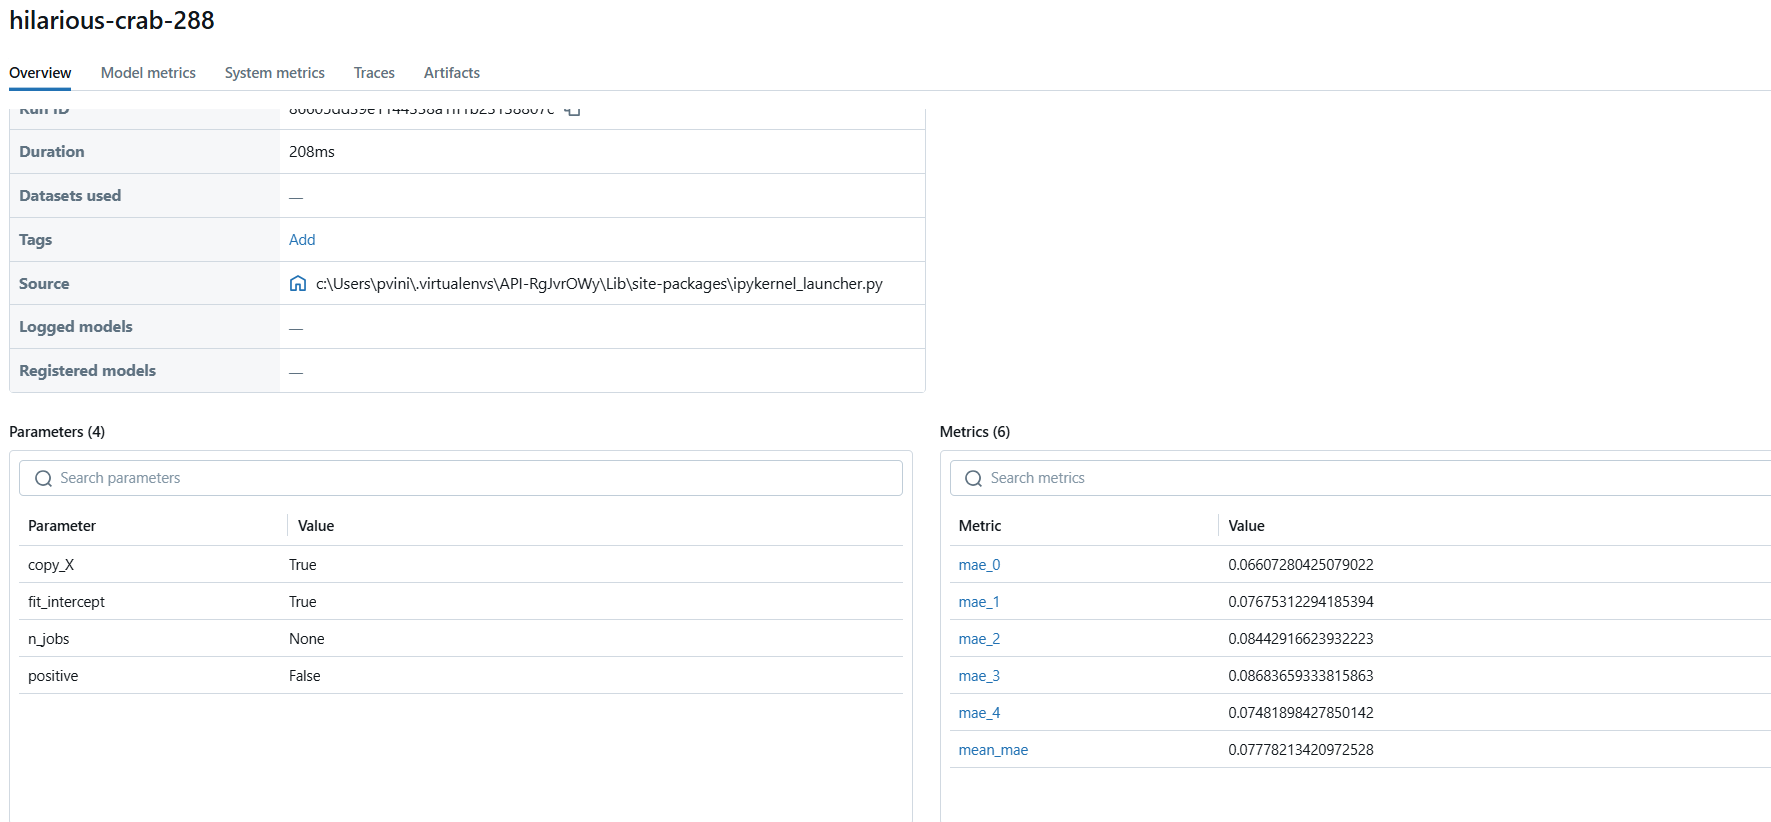


#### Resultados da arvore de decisão

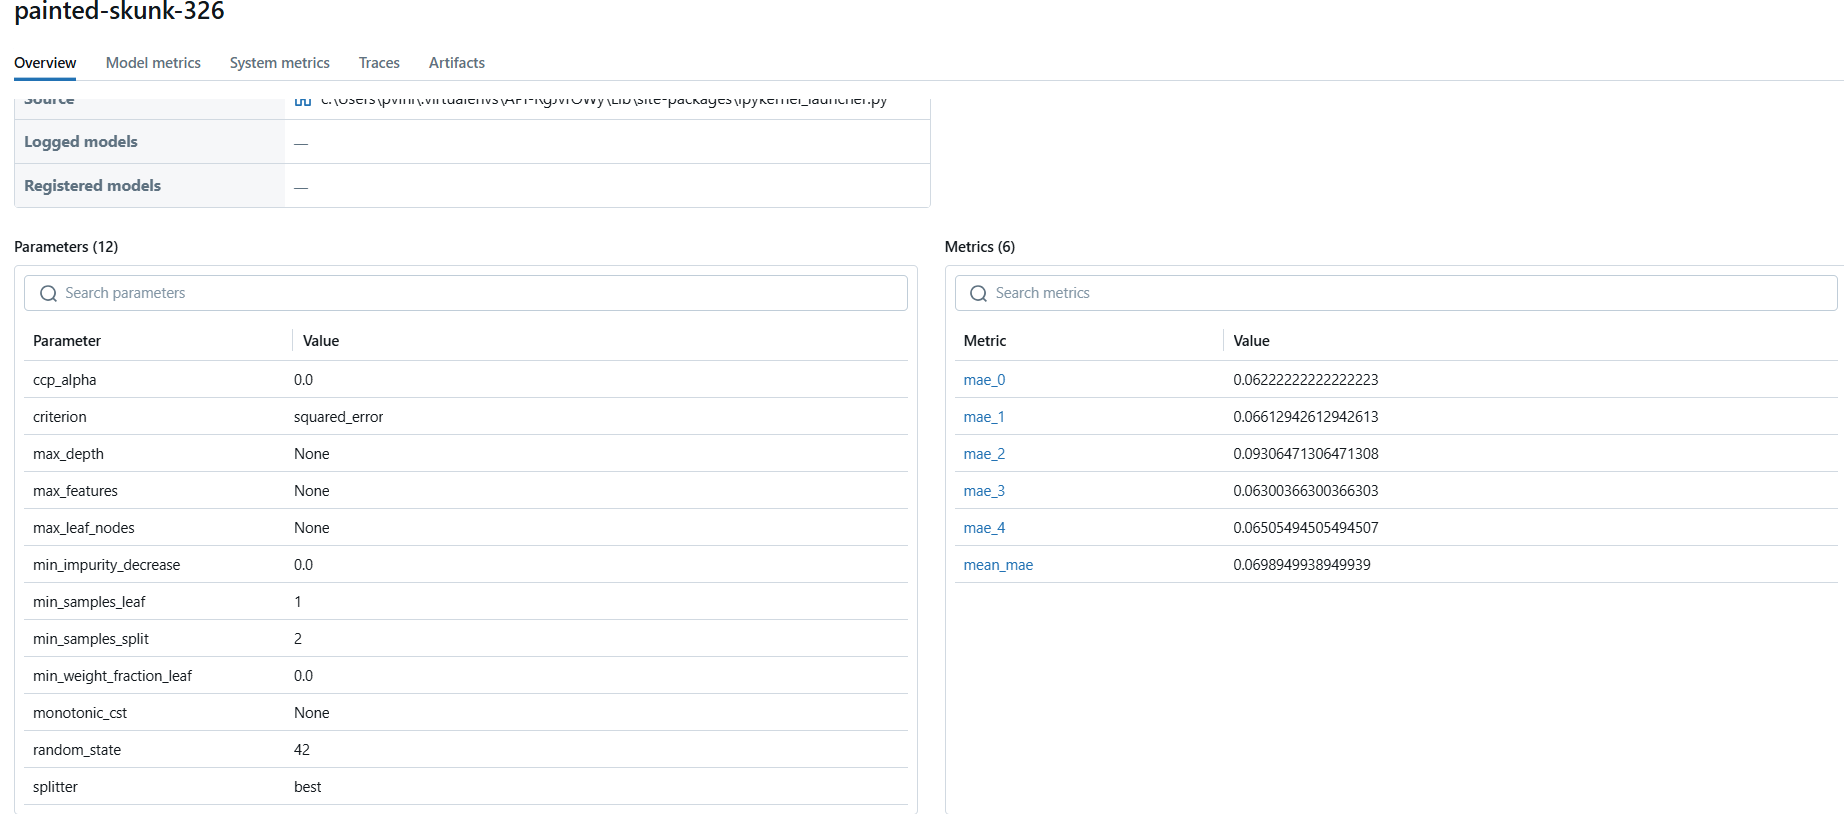


#### Resultados da Random Forest

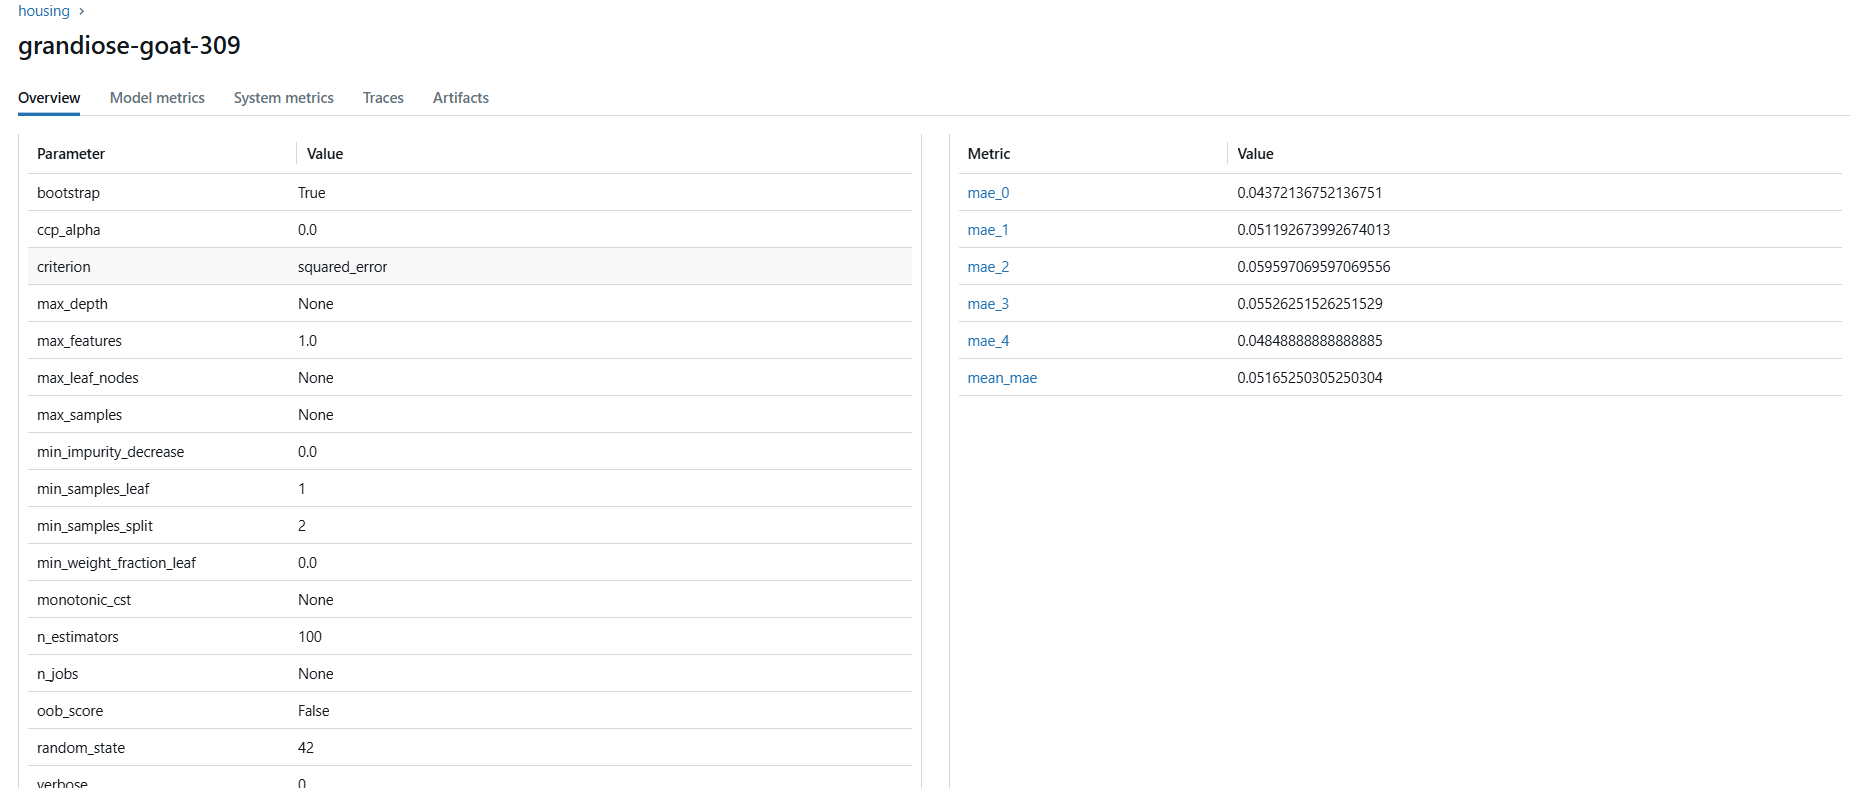

#### para uma melhor avaliação eu loggei a média dos resultados do MAE assim poderiamos ter uma métrica unica


### Experimentos Executados

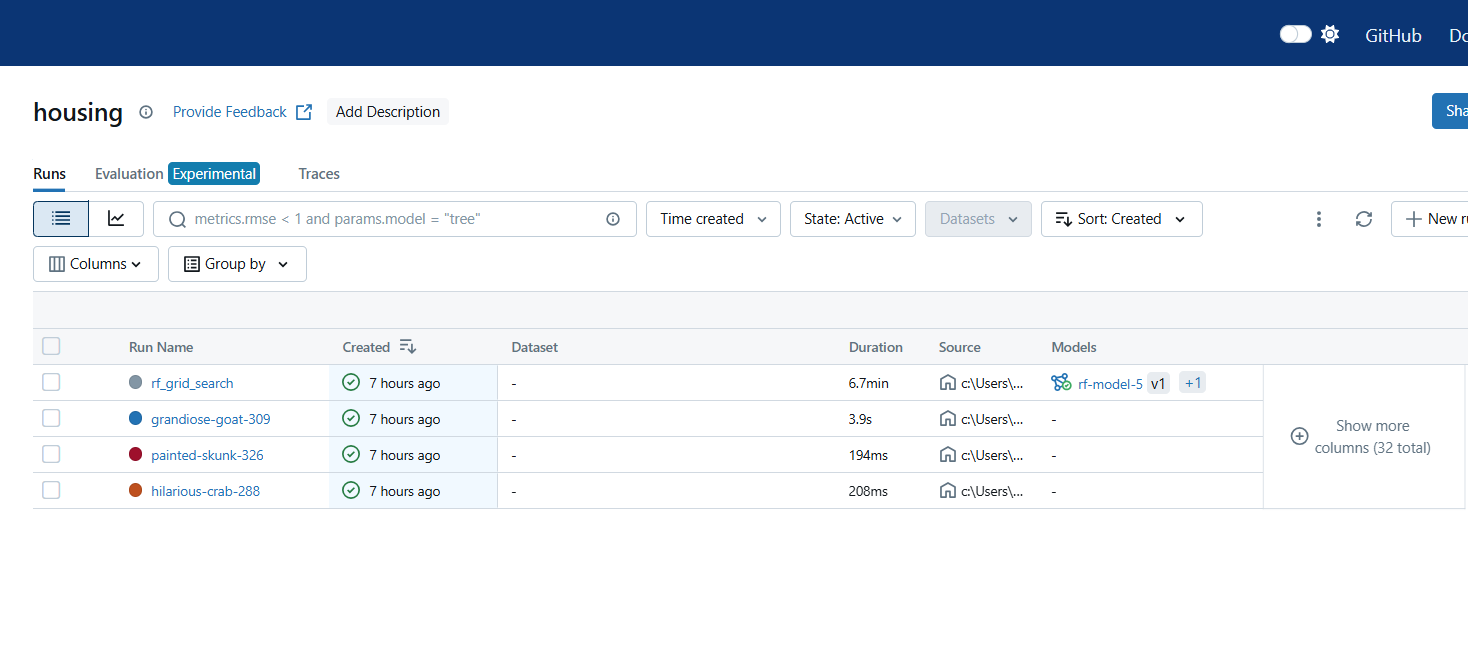
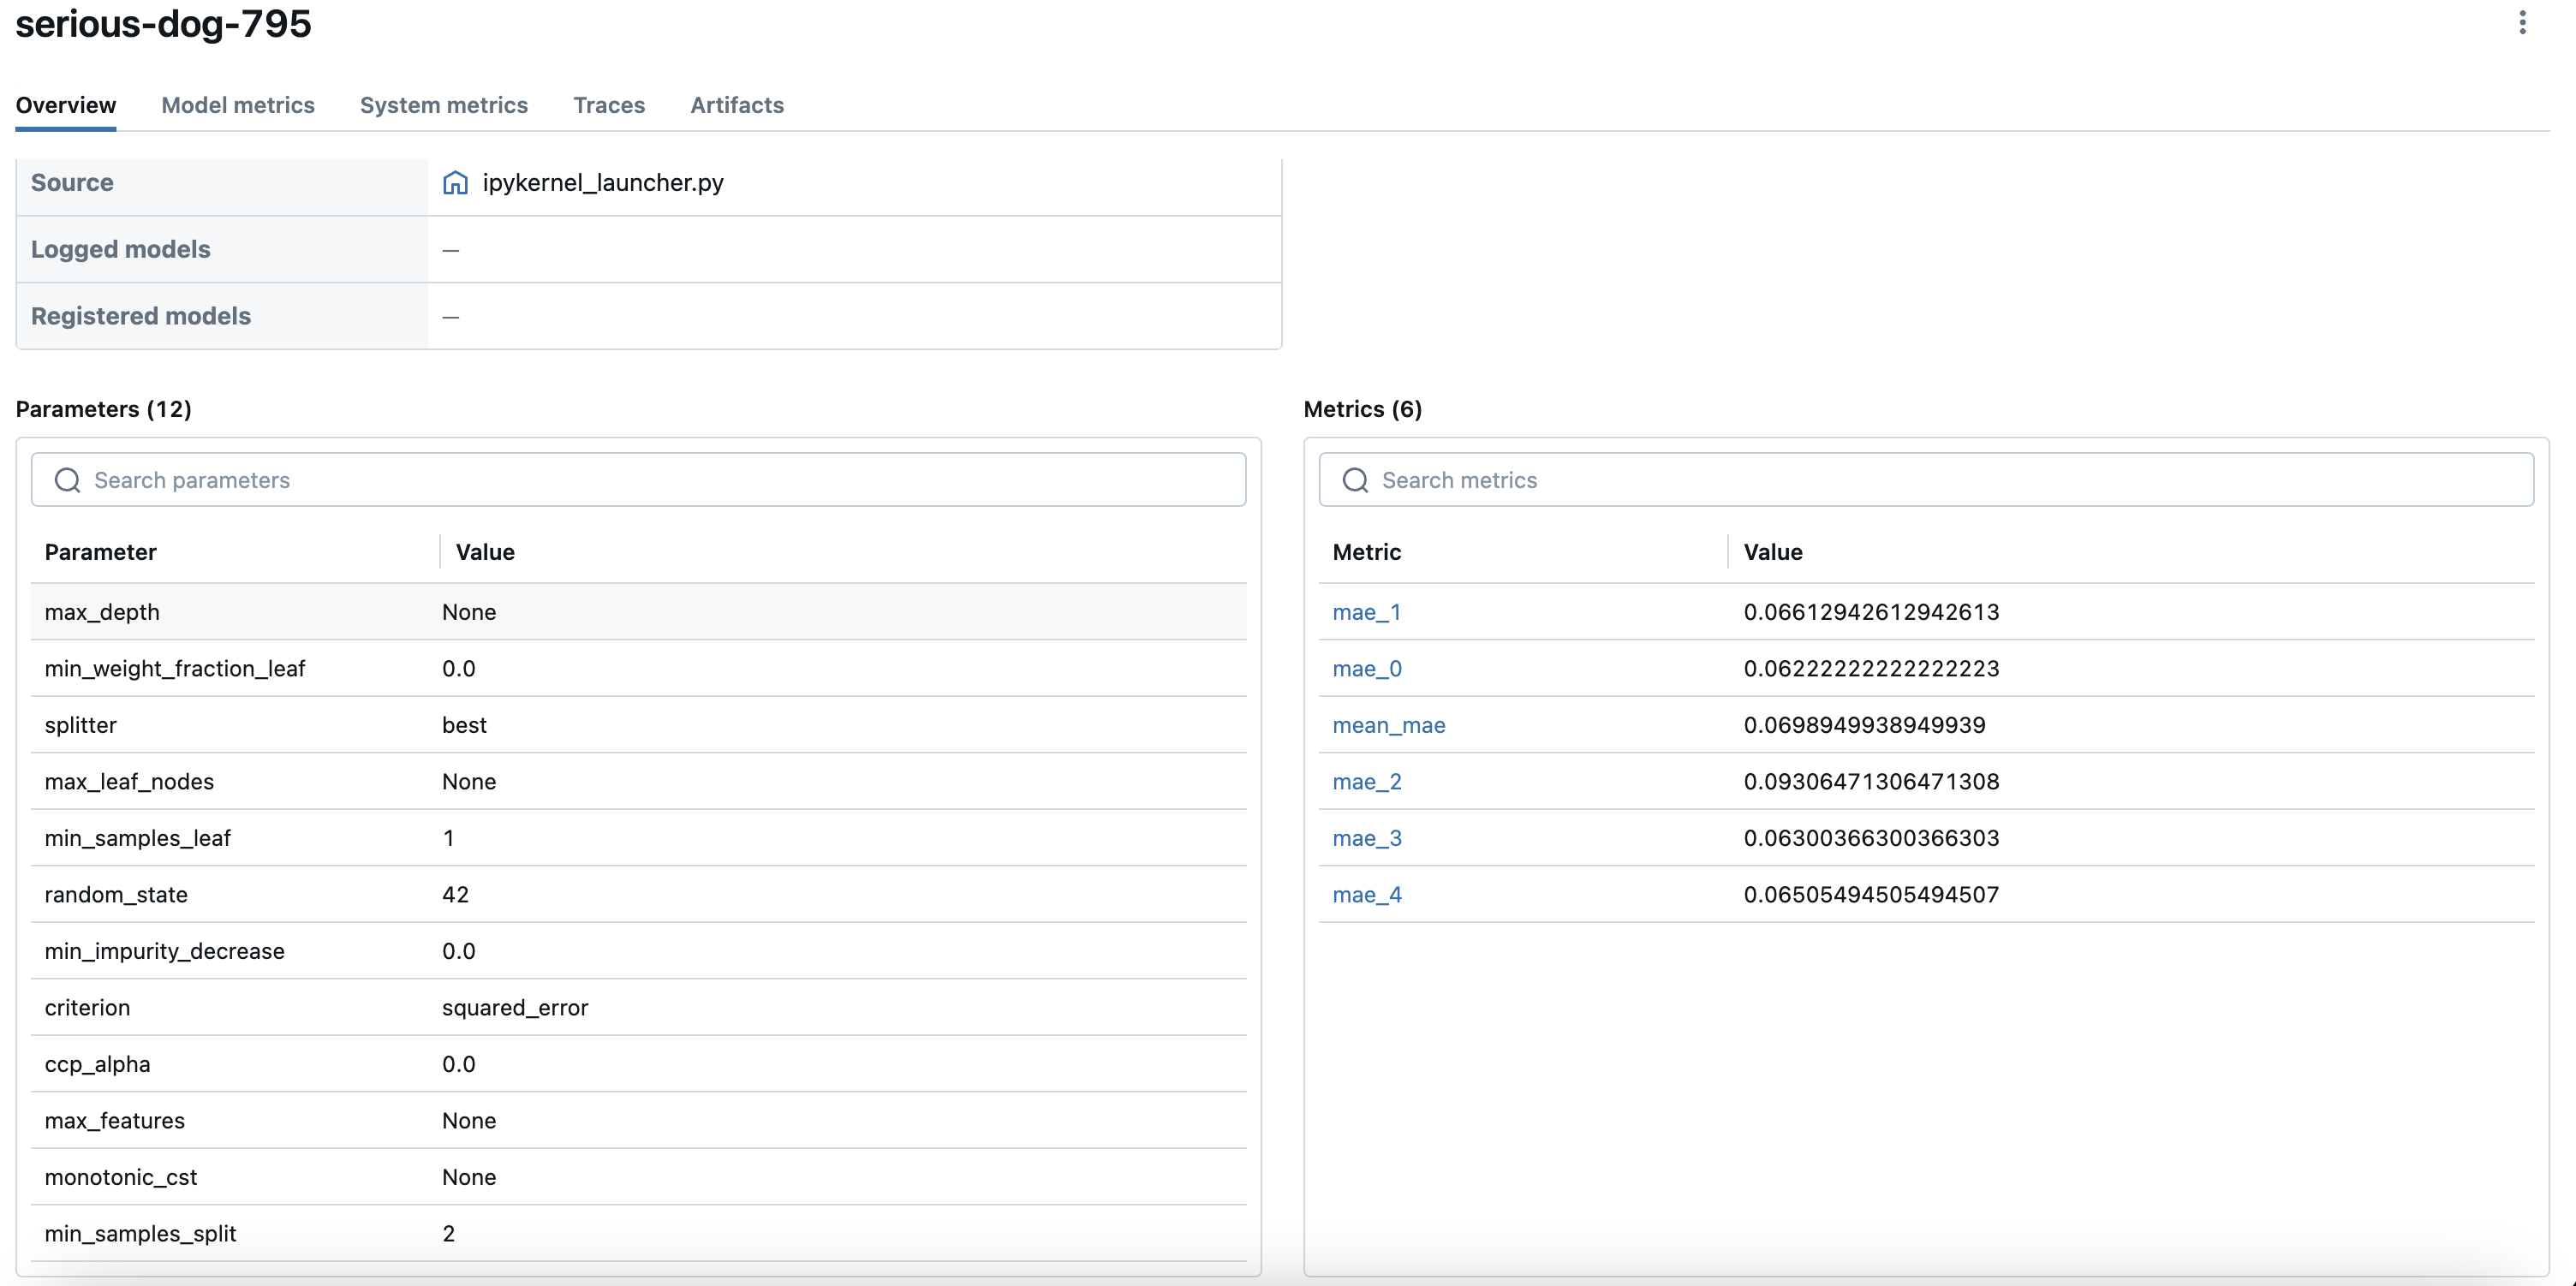
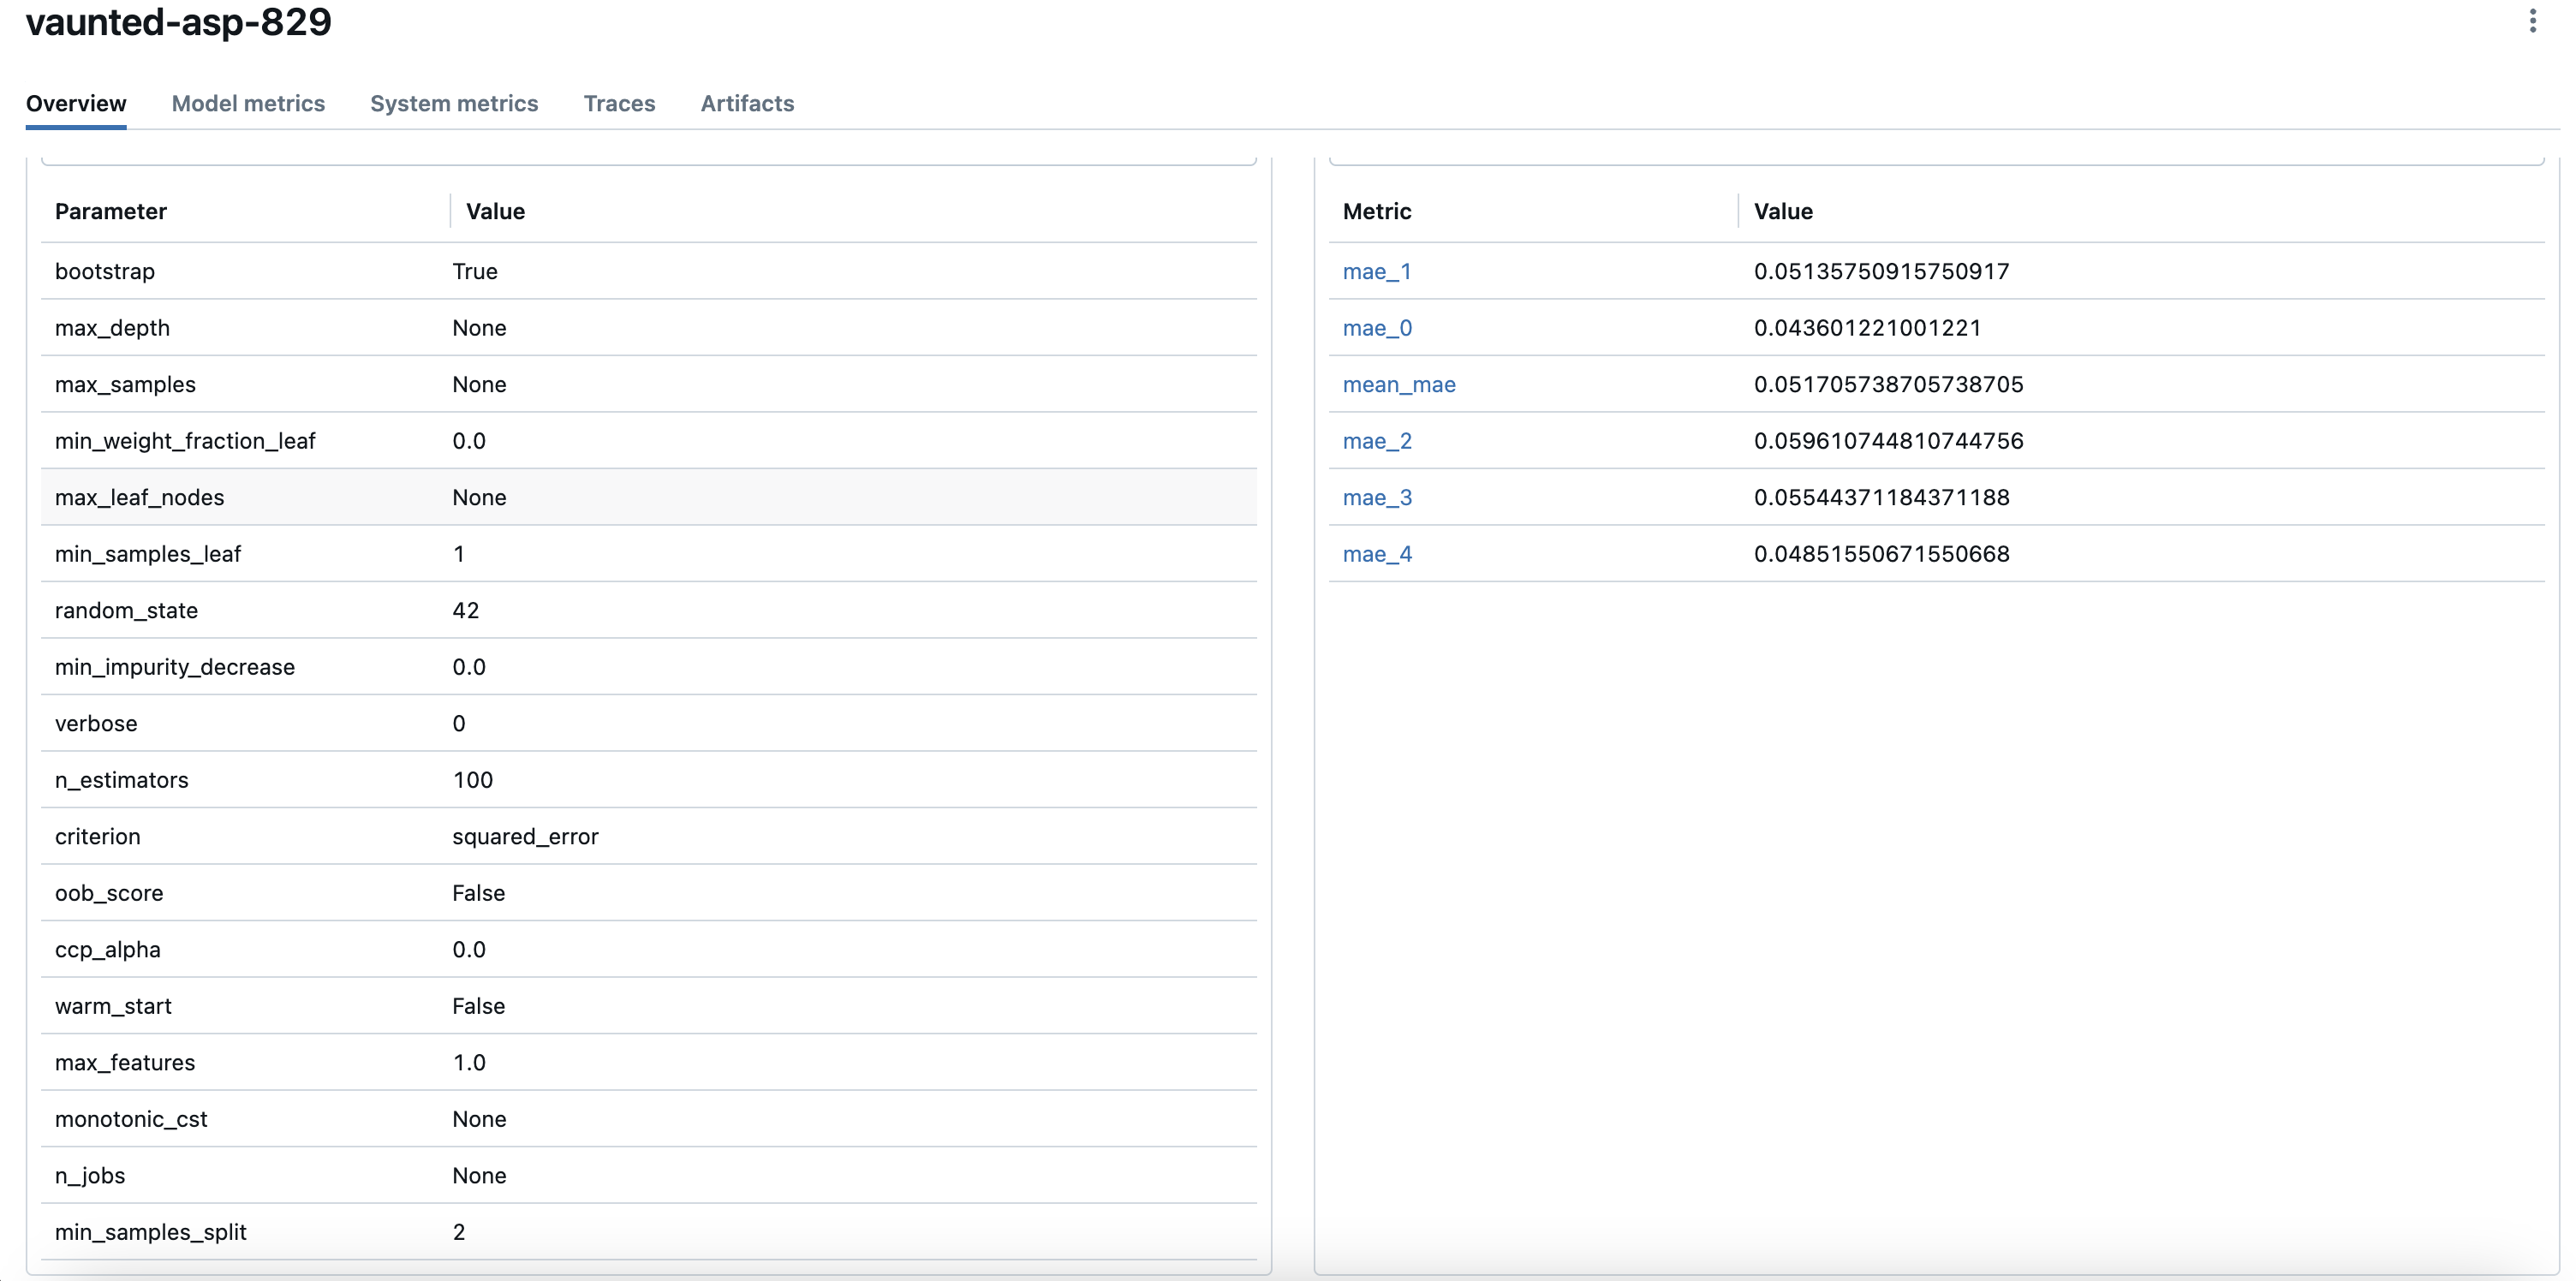
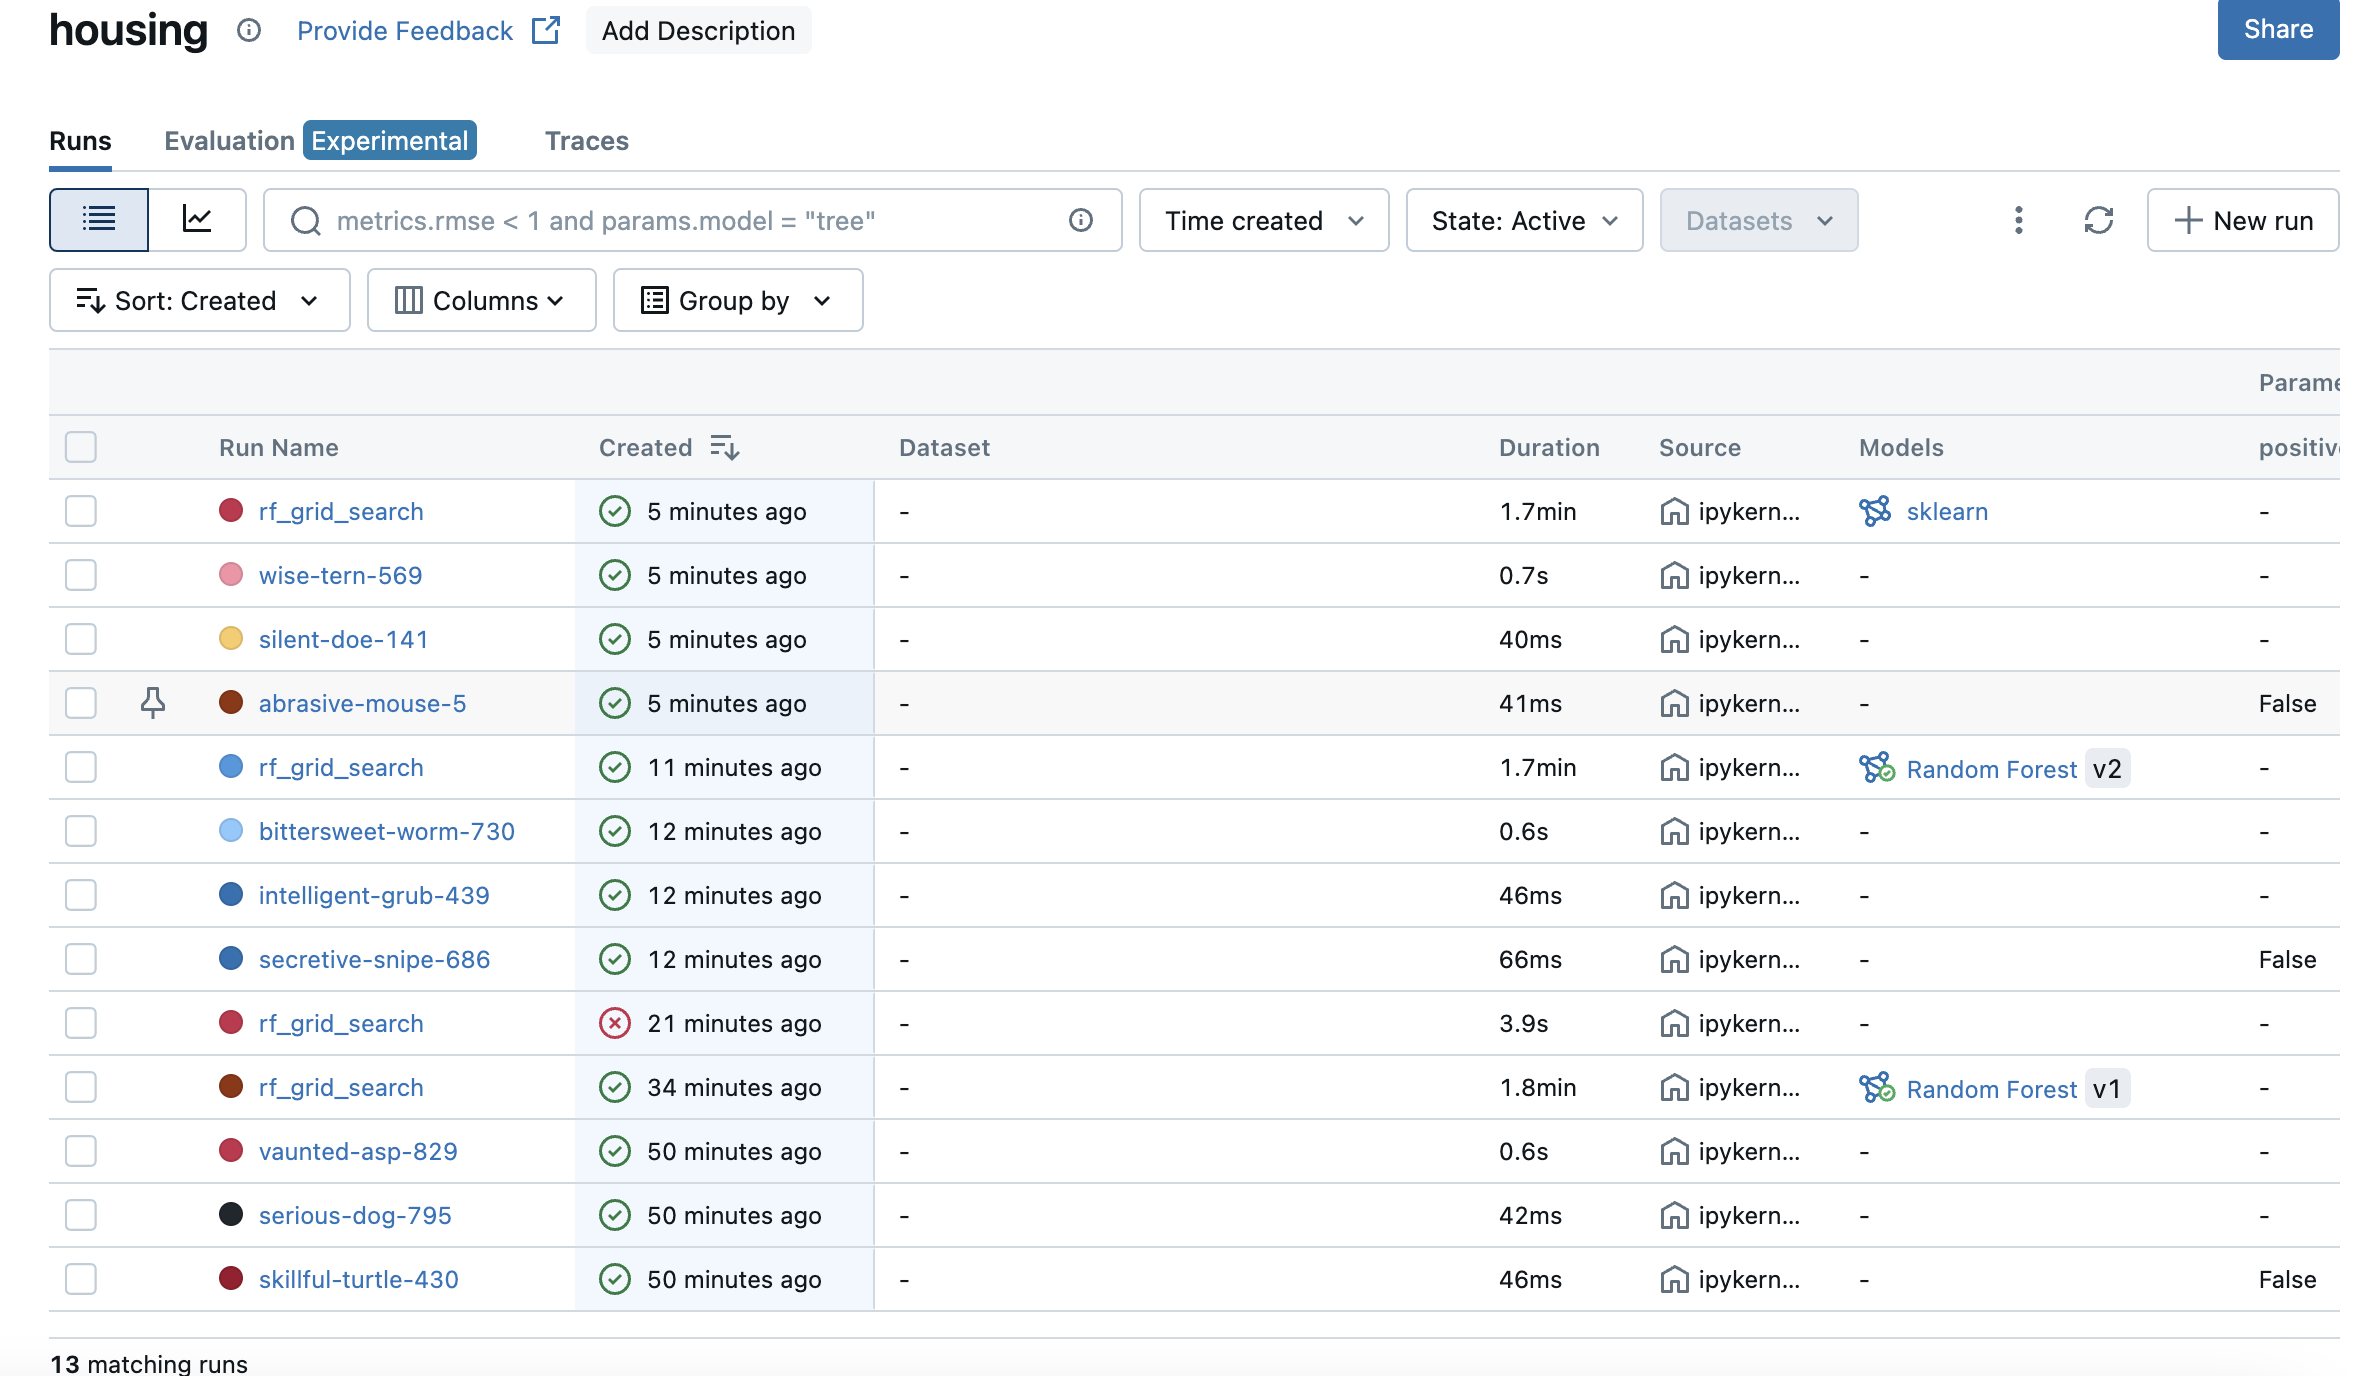
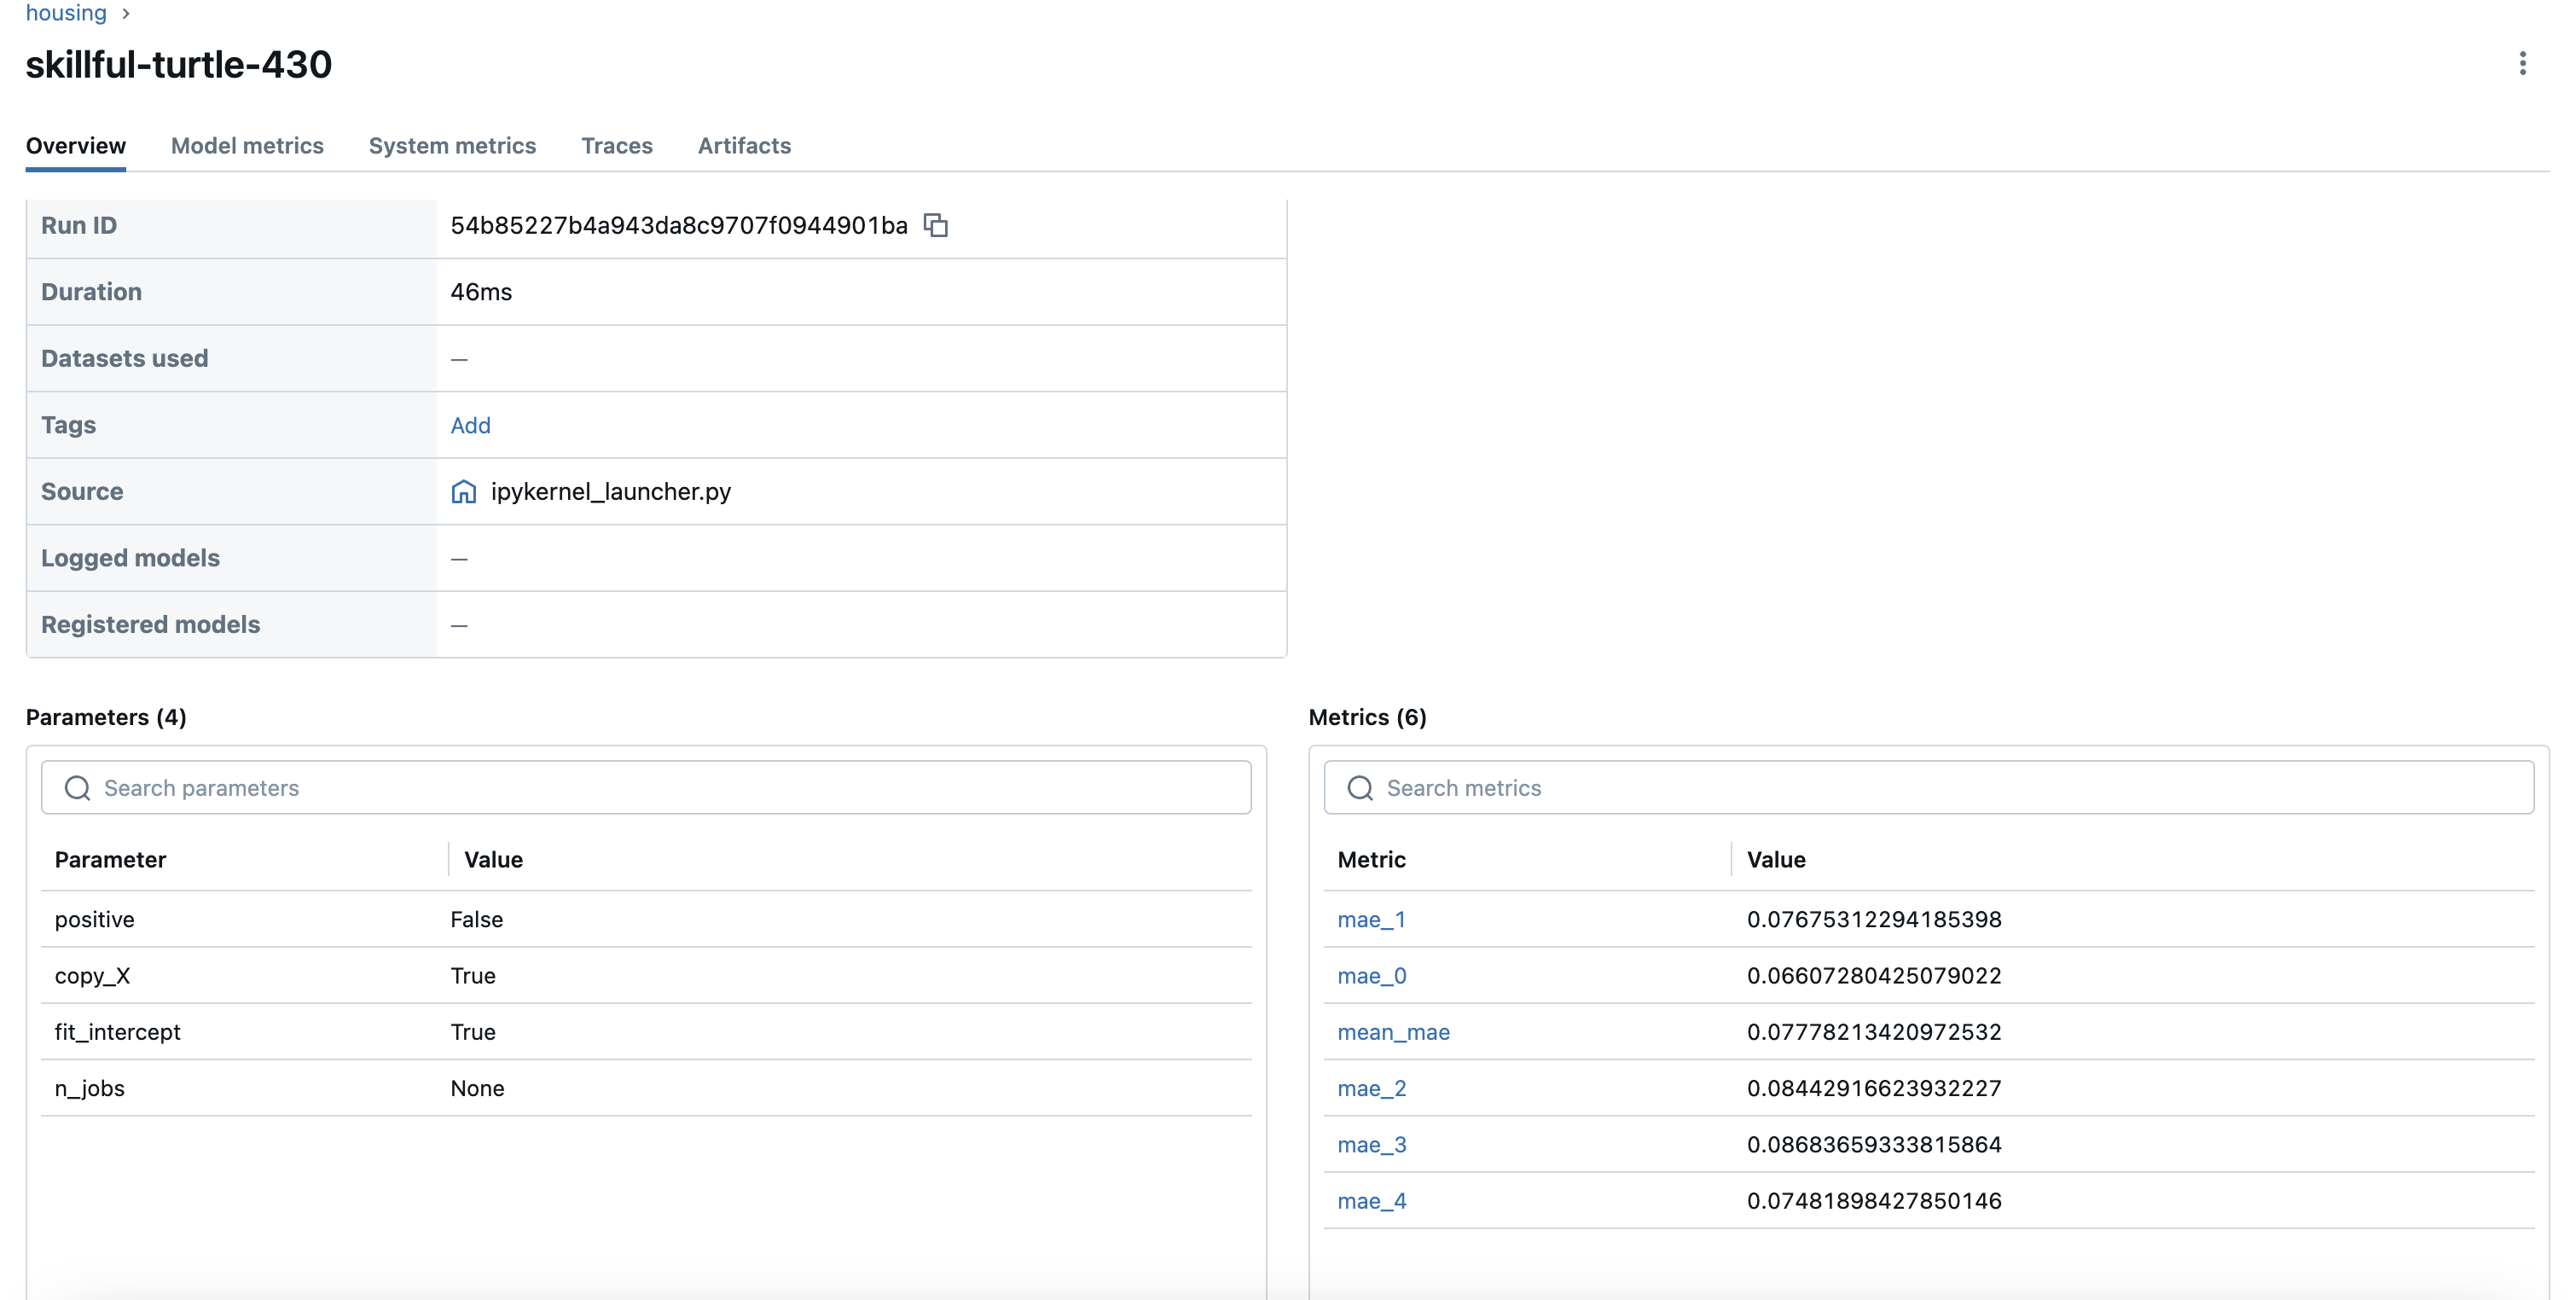

Comparando os a arvore de decisão e a regressão linear, podemos dizer que a arvore de decisão se saiu melhor. Os dados não possuem relações lineares altas  e a distribuição dos dados que não é gaussiana faz com que a regressão linear, um algoritmo que pressupõe linearidade entre as variáveis não consiga se adaptar, diferente da árvore de decisão que consegue se adaptar melhor com relação não lineares entre as variaveis.


Posteriormente foi decidido fazer testes com o Random Forest, que obteve resultados melhores que as a arvore de decisão. Talvez a Randoom Forest não sofra tanto de overfitting quanto as arvores de decisão

Sendo assim o melhor modelo foi Random Forest com previsões estando a 5% de distância aproximadamente dos valores reais

In [ ]:
import mlflow
import mlflow.sklearn
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor


mlflow.set_tracking_uri("http://127.0.0.1:6002")

param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search_rf = GridSearchCV(RandomForestRegressor(), param_grid_rf, cv=5, scoring='neg_mean_absolute_error')

with mlflow.start_run(run_name="rf_grid_search"):
    grid_search_rf.fit(X, y)

    best_model = grid_search_rf.best_estimator_
    best_params = grid_search_rf.best_params_
    best_score = -grid_search_rf.best_score_

    input_example = X.iloc[[0]]

    mlflow.log_params(best_params)
    mlflow.log_metric("mae", best_score)
    mlflow.sklearn.log_model(best_model, "rf-model-5", input_example=input_example)

    model_uri = "runs:/{}/rf-model".format(mlflow.active_run().info.run_id)
    model_name = "rf-model-5"
    
    registered_model = mlflow.register_model(model_uri, model_name)

    print(f"Modelo registrado com sucesso: {registered_model.name}, versão: {registered_model.version}")

c:\Users\pvini\.virtualenvs\API-RgJvrOWy\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025/01/27 12:11:42 INFO mlflow.models.model: Found the following environment variables used during model inference: [OPENAI_API_KEY]. Please check if you need to set them when deploying the model. To disable this message, set environment variable `MLFLOW_RECORD_ENV_VARS_IN_MODEL_LOGGING` to `false`.
Successfully registered model 'rf-model-5'.
2025/01/27 12:11:42 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: rf-model-5, version 1


Modelo registrado com sucesso: rf-model-5, versão: 1
🏃 View run rf_grid_search at: http://127.0.0.1:6002/#/experiments/1/runs/ff6db848f6b44367a5a2f3d93e101c58
🧪 View experiment at: http://127.0.0.1:6002/#/experiments/1


Created version '1' of model 'rf-model-5'.


In [9]:
print("Melhores hiperparâmetros para Random Forest:", grid_search_rf.best_params_)
print("Melhor MAE para Random Forest:", -grid_search_rf.best_score_)

# modelo otimizados
best_rf_model = grid_search_rf.best_estimator_

Melhores hiperparâmetros para Random Forest: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
Melhor MAE para Random Forest: 0.0655382147771099


### Performance da Random Forest depois de otimização de hiperparametros

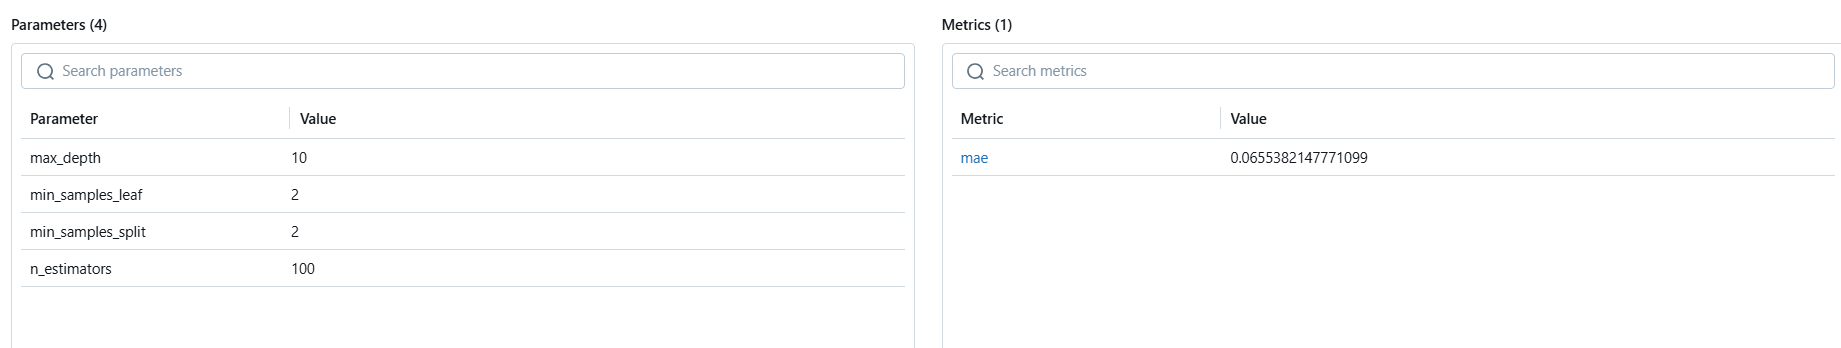

um MAE de 0.06 na escala normalizada corresponderia a um erro médio de 0.06 * 22.500 (média do preço mediano das casas) = US$ 1.350 nas previsões.
Um erro de 0.06 poderia ser ruim dependendo do preço da casa e de outros fatores. Se o modelo subestima o preço do imovel, isso pode ser ruim para o comprador, pois ele pode se sentir enganado ao descobrir que o preço da casa na verdade era mais caro, pois ele iniciou o processo de compra, tudo para no final descobrir que o preço era mais caro. E ruim para o vendedor pois pode forçar ele a vender um imovel por um preço mais abaixo em relação ao mercado. Caso ao contrário, se o modelo superestima o valor, uma oferta inicial muito alta pode afastar compradores.



#### Depois de escolhermos o modelo com melhor performance, criamos nosso modelo final sendo representado pelo modelo com Algoritmo de Random Forest, e loggamos finalmente o modelo



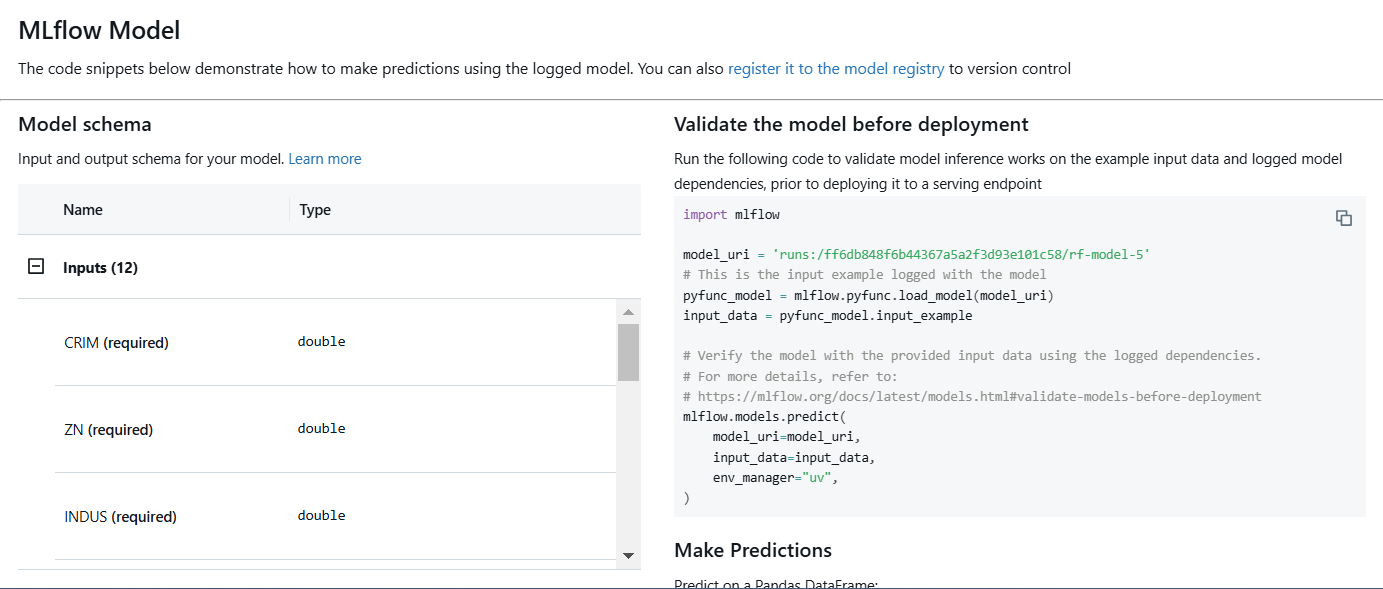
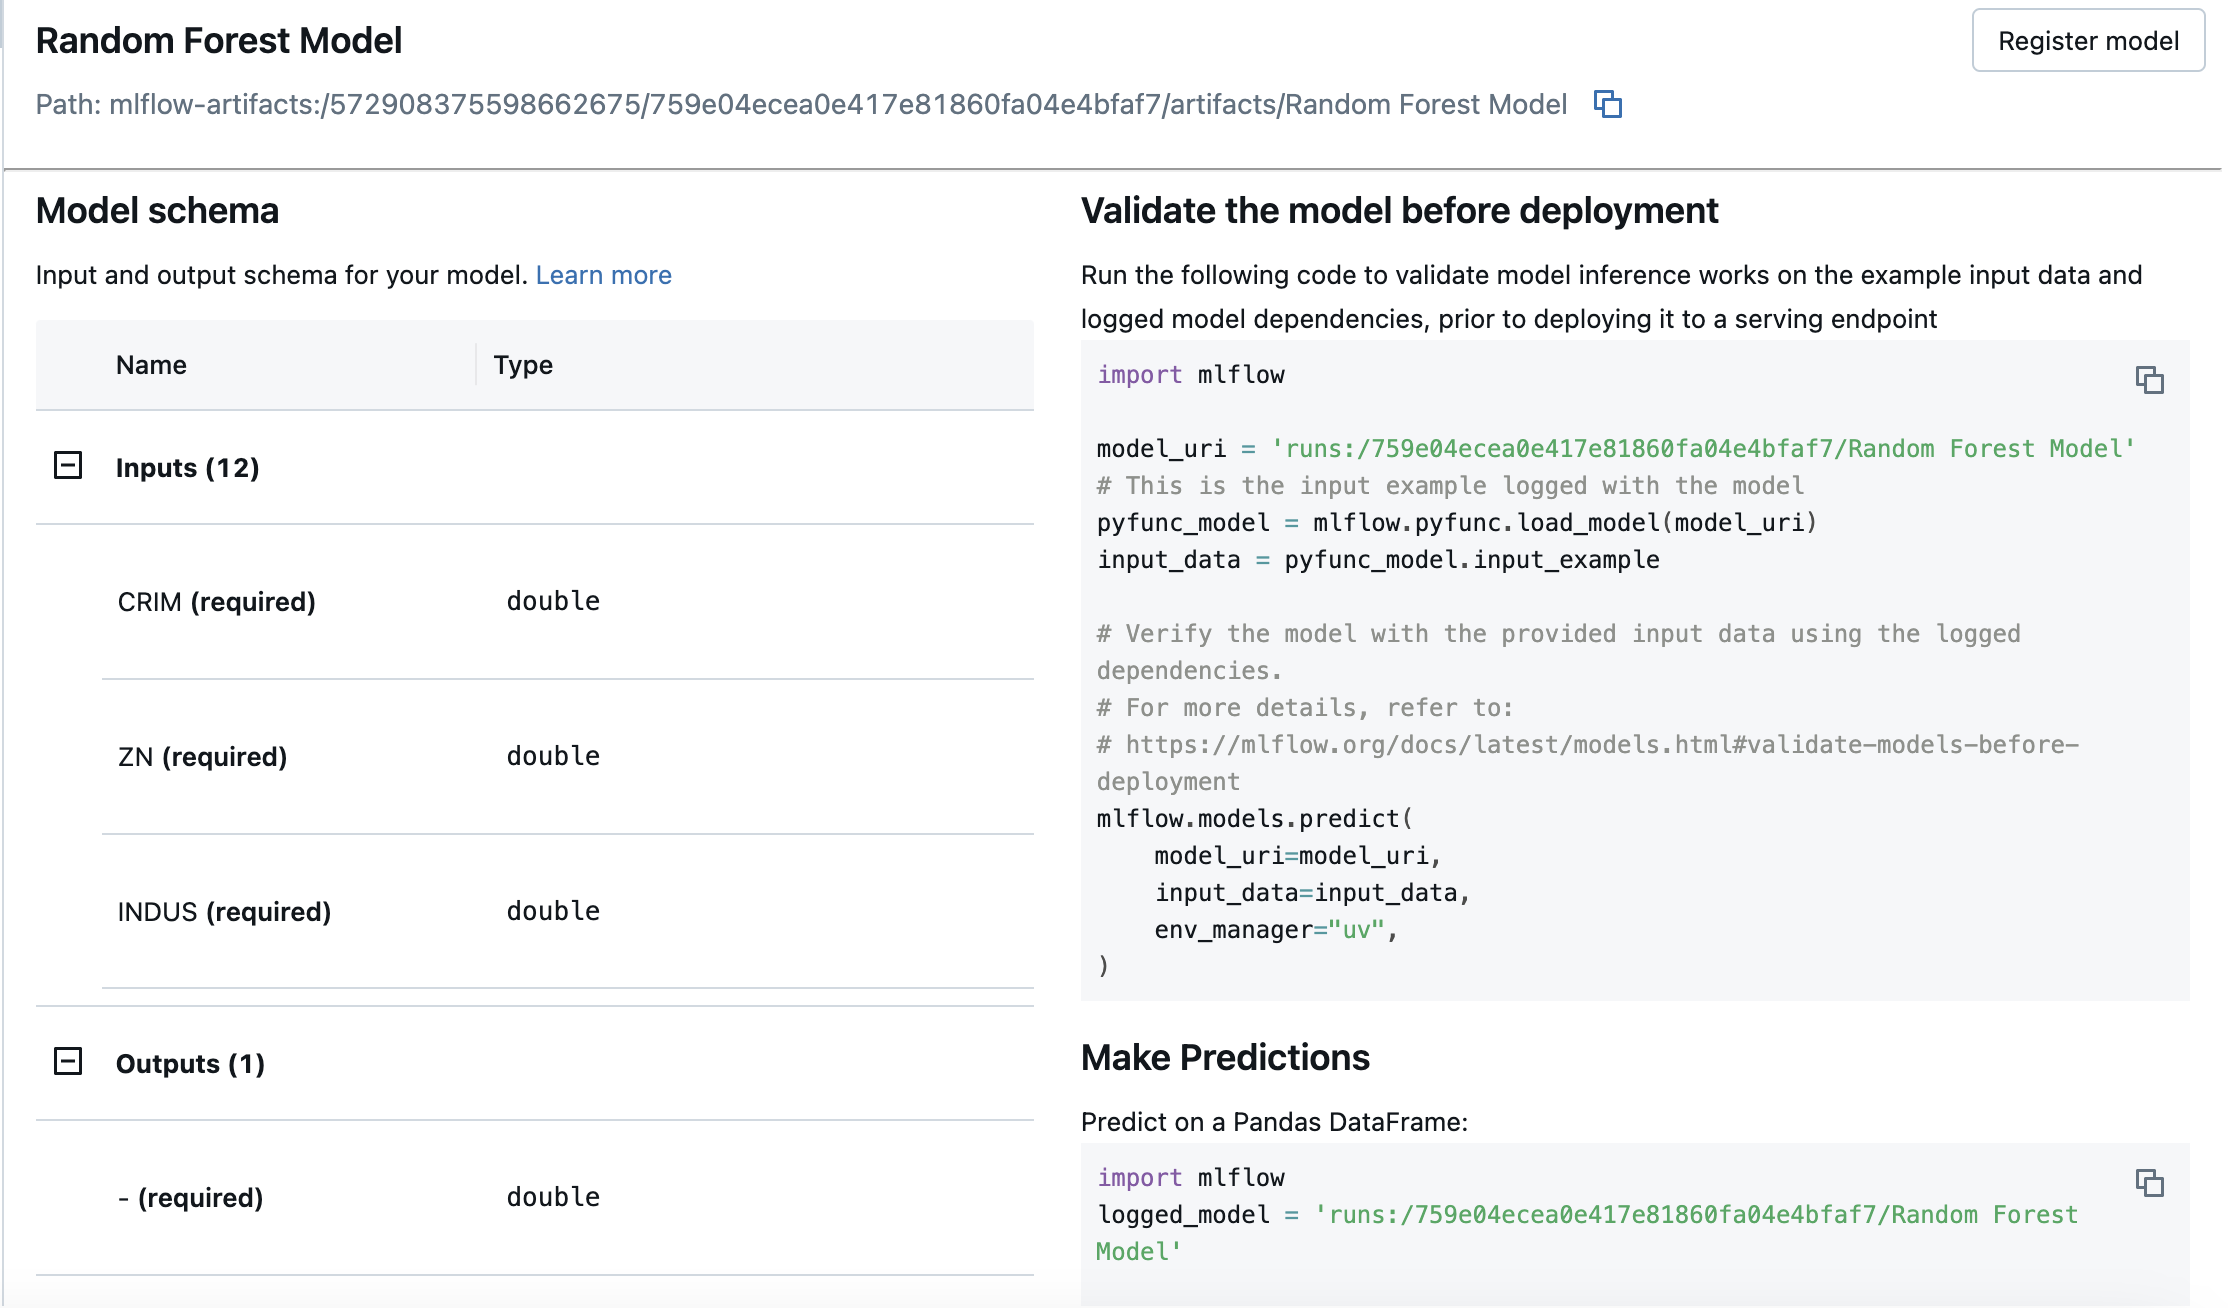

### Carregando modelo registrado do MLFlow

In [10]:
mlflow.search_registered_models()


[<RegisteredModel: aliases={}, creation_timestamp=1737990702483, description='', last_updated_timestamp=1737990702554, latest_versions=[<ModelVersion: aliases=[], creation_timestamp=1737990702554, current_stage='None', description='', last_updated_timestamp=1737990702554, name='rf-model-5', run_id='ff6db848f6b44367a5a2f3d93e101c58', run_link='', source='file:///C:/Users/pvini/Downloads/code-assignment/code-assignment/mlruns/1/ff6db848f6b44367a5a2f3d93e101c58/artifacts/rf-model', status='READY', status_message=None, tags={}, user_id='', version='1'>], name='rf-model-5', tags={}>]

In [11]:
! pip install uv 


[notice] A new release of pip is available: 23.3 -> 25.0
[notice] To update, run: python.exe -m pip install --upgrade pip


### EXEMPLO DADO PELO MLFLOW PARA TESTAR A INFERÊNCIA

In [14]:


import mlflow

model_uri = 'runs:/ff6db848f6b44367a5a2f3d93e101c58/rf-model-5'
# This is the input example logged with the model
pyfunc_model = mlflow.pyfunc.load_model(model_uri)
input_data = pyfunc_model.input_example

# Verify the model with the provided input data using the logged dependencies.
# For more details, refer to:
# https://mlflow.org/docs/latest/models.html#validate-models-before-deployment
pyfunc_model.predict(
    input_data
)

array([0.47256074])